# Bilayer graphene

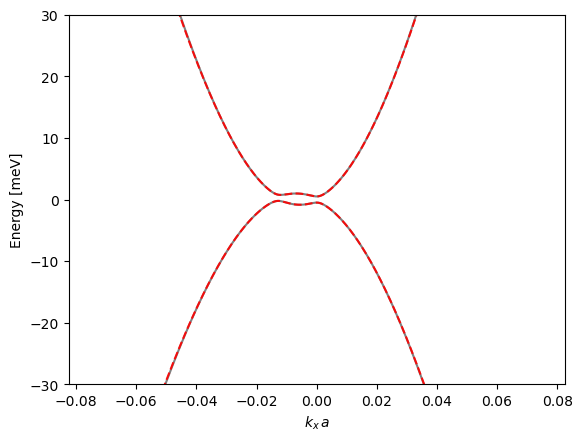

In [2]:
import jax 
import jax.numpy as jnp # or use np instead of jax.numpy
# import numpy as np

import contimod_graphene as cm_graphene

params = cm_graphene.graphene_params_BLG
params['U'] = 1

h_blg_2bands = cm_graphene.rhombohedral.get_2band_hamiltonian(n_layers=2, params=params)
h_blg = cm_graphene.rhombohedral.get_hamiltonian(n_layers=2, params=params)
# h_blg is callable with arguments kx, ky

k_lin = 0.15 * jnp.linspace(-0.5,0.5,800)
ks_path = jnp.array([[kx,0] for kx in k_lin]) # k-path

hs_path = jax.vmap(h_blg, in_axes=(0,0))(*ks_path.T) # list of h(k) along path
# or hs_path = np.array([h_blg(*k) for k in ks_path]) but is slower
bands_path = jnp.linalg.eigvalsh(hs_path) # list of eigenvalues along path

hs_path_2bands = jax.vmap(h_blg_2bands, in_axes=(0,0))(*ks_path.T) # list of h(k) along path
bands_path_2bands = jnp.linalg.eigvalsh(hs_path_2bands) # list of eigenvalues along path

# Plotting bands
import matplotlib.pyplot as plt

for band in bands_path.T:
    # plt.scatter(k_lin, band, s=3, color='black', alpha=0.5)
    plt.plot(k_lin, band, color='black', linewidth=1.5, alpha=0.5)
for band in bands_path_2bands.T:
    plt.plot(k_lin, band, color='red', linewidth=1.5, linestyle="--", alpha=0.9)

plt.xlabel(r"$k_x \, a$")
plt.ylabel(r"Energy [meV]")
plt.ylim(-30,30)
plt.show()

# Trilayer

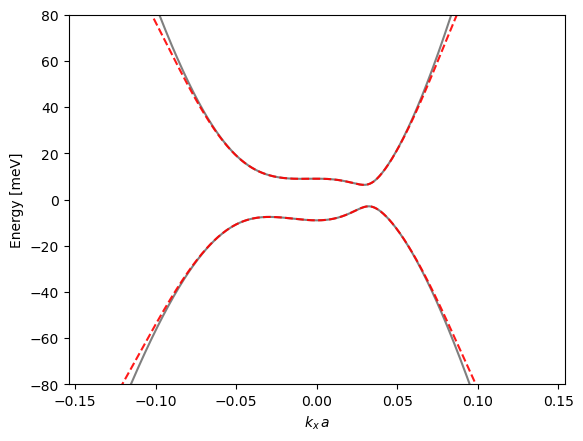

In [3]:
import jax 
import jax.numpy as jnp # or use np instead of jax.numpy
# import numpy as np

import contimod_graphene as cm_graphene

params = cm_graphene.graphene_params_TLG
params['U'] = 10

h_blg_2bands = cm_graphene.rhombohedral.get_2band_hamiltonian(n_layers=3, params=params)
h_blg = cm_graphene.rhombohedral.get_hamiltonian(n_layers=3, params=params)
# h_blg is callable with arguments kx, ky

k_lin = 0.28 * jnp.linspace(-0.5,0.5,800)
ks_path = jnp.array([[kx,0] for kx in k_lin]) # k-path

hs_path = jax.vmap(h_blg, in_axes=(0,0))(*ks_path.T) # list of h(k) along path
# or hs_path = np.array([h_blg(*k) for k in ks_path]) but is slower
bands_path = jnp.linalg.eigvalsh(hs_path) # list of eigenvalues along path

hs_path_2bands = jax.vmap(h_blg_2bands, in_axes=(0,0))(*ks_path.T) # list of h(k) along path
bands_path_2bands = jnp.linalg.eigvalsh(hs_path_2bands) # list of eigenvalues along path

# Plotting bands
import matplotlib.pyplot as plt

for band in bands_path.T:
    # plt.scatter(k_lin, band, s=3, color='black', alpha=0.5)
    plt.plot(k_lin, band, color='black', linewidth=1.5, alpha=0.5)
for band in bands_path_2bands.T:
    plt.plot(k_lin, band, color='red', linewidth=1.5, linestyle="--", alpha=0.9)

plt.xlabel(r"$k_x \, a$")
plt.ylabel(r"Energy [meV]")
plt.ylim(-80,80)
plt.show()

# 5-layer 

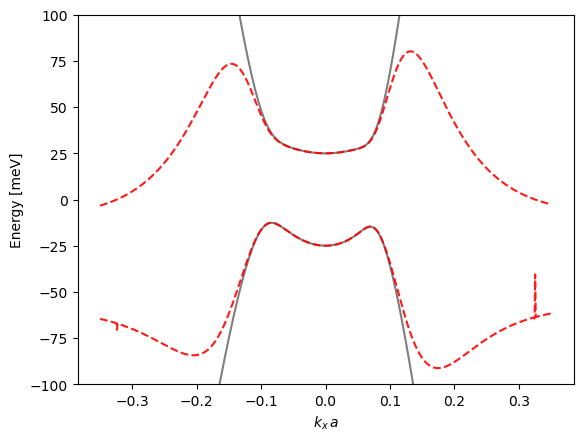

In [4]:
import jax 
import jax.numpy as jnp # or use np instead of jax.numpy
# import numpy as np

import contimod_graphene as cm_graphene

# Set momentum path
k_lin = 0.7 * jnp.linspace(-0.5,0.5,800) # in units of 1/a
ks_path = jnp.array([[kx,0] for kx in k_lin]) # k-path

# Set hamiltonian parameters
params = cm_graphene.graphene_params_TLG
params['U'] = 50 # interlayer potential in meV

# Get hamiltonian and calculate bands
h_blg = cm_graphene.rhombohedral.get_hamiltonian(n_layers=5, params=params) # h_blg is callable with arguments kx, ky
hs_path = jax.vmap(h_blg, in_axes=(0,0))(*ks_path.T) # list of h(k) along path
# or hs_path = np.array([h_blg(*k) for k in ks_path]) but is slower
bands_path = jnp.linalg.eigvalsh(hs_path) # list of eigenvalues along path

# Get hamiltonian and calculate bands for 2-band model
h_blg_2bands = cm_graphene.rhombohedral.get_2band_hamiltonian(n_layers=5, params=params)
hs_path_2bands = jax.vmap(h_blg_2bands, in_axes=(0,0))(*ks_path.T) # list of h(k) along path
bands_path_2bands = jnp.linalg.eigvalsh(hs_path_2bands) # list of eigenvalues along path

# Plotting bands
import matplotlib.pyplot as plt

for band in bands_path.T:
    # plt.scatter(k_lin, band, s=3, color='black', alpha=0.5)
    plt.plot(k_lin, band, color='black', linewidth=1.5, alpha=0.5)
for band in bands_path_2bands.T:
    plt.plot(k_lin, band, color='red', linewidth=1.5, linestyle="--", alpha=0.9)

plt.xlabel(r"$k_x \, a$")
plt.ylabel(r"Energy [meV]")
plt.ylim(-100,100)
plt.show()